In [1]:
# ==============================================================================
# --- 1. Import Libraries ---
# ==============================================================================
from IPython.display import display, HTML
display(HTML("<style>:root { --jp-notebook-max-width: 80% !important; }</style>"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
import pickle
from sklearn.mixture import GaussianMixture

In [2]:
# ==============================================================================
# --- 2. Configuration: Define Portable File Paths ---
# ==============================================================================

# This finds the root of your 'schlegel-et-al-2025' folder regardless of where it is on a computer
SCRIPT_DIR = os.path.dirname(os.path.abspath(__file__)) if '__file__' in locals() else os.getcwd()
BASE_DIR = os.path.join(os.path.dirname(SCRIPT_DIR), "data", "hic")

FILE_PATHS = {
    # Maize Datasets
    'maize_leaf_hic': os.path.join(BASE_DIR, "maize_HiC_leaf_loops.bedpe"),
    'maize_ear_hic': os.path.join(BASE_DIR, "maize_HiC_ear_loops.bedpe"),
    'maize_tassel_hic': os.path.join(BASE_DIR, "maize_HiC_tassel_loops.bedpe"),
    
    # Rice Datasets
    'rice_leaf_hic': os.path.join(BASE_DIR, "rice_leaf_HiC.hiccups_loops.fdr0.1.bedpe"),
    'rice_mesophyll_hic': os.path.join(BASE_DIR, "rice_mesophyll_uniform.bedpe"),
    'rice_endosperm_hic': os.path.join(BASE_DIR, "rice_endosperm_uniform.bedpe"),
    
    # Soybean Datasets
    'soybean_leaf_hic': os.path.join(BASE_DIR, "soybean_leaf_HiC.hiccups_loops.fdr0.1.bedpe"),
    'soybean_cotyledon_dark_hic': os.path.join(BASE_DIR, "soybean_cotyledon_dark_uniform.bedpe"),
    'soybean_cotyledon_light_hic': os.path.join(BASE_DIR, "soybean_cotyledon_light_uniform.bedpe"),
    'soybean_hypocotyl_dark_hic': os.path.join(BASE_DIR, "soybean_hypocotyl_dark_uniform.bedpe"),
    'soybean_hypocotyl_light_hic': os.path.join(BASE_DIR, "soybean_hypocotyl_light_uniform.bedpe"),
    'soybean_hook_dark_hic': os.path.join(BASE_DIR, "soybean_hook_dark_uniform.bedpe"),
    'soybean_hook_light_hic': os.path.join(BASE_DIR, "soybean_hook_light_uniform.bedpe")
}

PROCESSED_HIC_DATA = {}

In [3]:
# ==============================================================================
# --- 3. Data Processing and Merging Functions ---
# ==============================================================================

def process_hic_file(path, label):
    """Loads BEDPE files, calculates mid-point distances, and standardizes columns."""
    try:
        # Load data, skipping comment lines
        df_raw = pd.read_csv(path, sep=r'\s+', engine="python", header=None, comment='#')
        
        # Standardize to 6-column architecture
        df = df_raw.iloc[:, :6].copy()
        df.columns = ['chr1', 's1', 'e1', 'chr2', 's2', 'e2']
        
        # Robust prefix removal (chr, GM, etc.)
        for col in ['chr1', 'chr2']:
            df[col] = df[col].astype(str).str.extract(r'(\d+)', expand=False)
            
        # Ensure numeric types
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')
        
        df.dropna(inplace=True)
        df = df.astype(int)
        
        # Calculate Midpoint Distance
        df['distance'] = abs(((df['s1'] + df['e1']) // 2) - 
                             ((df['s2'] + df['e2']) // 2))
        
        df = df.drop_duplicates()
        df = df[df['distance'] > 0].reset_index(drop=True)
        
        print(f"✅ Processed {label}: {len(df)} loops.")
        return df
        
    except Exception as e:
        print(f"❌ Skipping {label}: {e}")
        return None

def merge_species_normalized(keys, label):
    """Tissue-balanced merging: subsamples all datasets to the smallest count."""
    dfs = [PROCESSED_HIC_DATA[k] for k in keys if PROCESSED_HIC_DATA.get(k) is not None]
    if not dfs: 
        return None
    
    min_count = min(len(df) for df in dfs)
    print(f"--- Normalizing {label}: {min_count} loops per dataset ---")
    
    subsampled = [df.sample(n=min_count, random_state=42) for df in dfs]
    merged = pd.concat(subsampled, ignore_index=True).drop_duplicates()
    return merged

def get_tissue_balanced_soybean():
    """Custom Soybean balance: groups by tissue category before merging."""
    groups = {
        'leaf': ['soybean_leaf_hic'],
        'cotyledon': ['soybean_cotyledon_light_hic', 'soybean_cotyledon_dark_hic'],
        'hypocotyl': ['soybean_hypocotyl_light_hic', 'soybean_hypocotyl_dark_hic'],
        'hook': ['soybean_hook_light_hic', 'soybean_hook_dark_hic']
    }
    
    tissue_dfs = {}
    for tissue, keys in groups.items():
        dfs = [PROCESSED_HIC_DATA[k] for k in keys if PROCESSED_HIC_DATA.get(k) is not None]
        if dfs:
            tissue_dfs[tissue] = pd.concat(dfs, ignore_index=True).drop_duplicates()

    min_count = min(len(df) for df in tissue_dfs.values())
    print(f"\n--- Normalizing Soybean (Balanced Tissues) ---")
    
    final_list = [df.sample(n=min_count, random_state=42) for df in tissue_dfs.values()]
    merged = pd.concat(final_list, ignore_index=True).drop_duplicates()
    print(f"🏁 Created soybean_global_consensus: {len(merged)} loops.")
    return merged

def bin_and_count_distances(df, num_bins=150):
    """Transforms distance distribution into log-log space for GMM fitting."""
    if df is None or len(df) == 0:
        return None, None
    
    min_dist = max(1, df['distance'].min())
    max_dist = df['distance'].max()
    bins = np.logspace(np.log10(min_dist), np.log10(max_dist), num_bins + 1)
    
    df = df.copy()
    df['bin'] = pd.cut(df['distance'], bins=bins, labels=False, include_lowest=True)
    
    bin_counts = df.groupby('bin')['distance'].agg(['count', 'median']).reset_index()
    bin_counts.columns = ['bin', 'count', 'bin_midpoint']
    bin_counts = bin_counts[bin_counts['count'] > 0].copy()
    
    # [log10(distance), log10(count)]
    X_data = np.column_stack([
        np.log10(bin_counts['bin_midpoint']),
        np.log10(bin_counts['count'])
    ])
    
    return X_data, bin_counts

In [4]:
# ==============================================================================
# --- 4. Data Execution: Processing and Merging ---
# ==============================================================================

# 1. Process individual datasets and check for 5MB outliers simultaneously
long_range_stats = []
threshold_5mb = 5_000_000

print("--- Initializing Data Processing ---")
for label, path in FILE_PATHS.items():
    df = process_hic_file(path, label)
    if df is not None:
        PROCESSED_HIC_DATA[label] = df
        
        # Calculate stats for transparency
        total = len(df)
        above_5mb = len(df[df['distance'] > threshold_5mb])
        long_range_stats.append({
            "Dataset": label, "Total": total, 
            ">5Mb": above_5mb, "% >5Mb": round((above_5mb/total*100), 2)
        })

# Display outlier summary (helpful for the reviewer to see data quality)
df_long_range = pd.DataFrame(long_range_stats)
print("\n--- Long-Range Outlier Summary (>5MB) ---")
print(df_long_range.to_string(index=False))

# 2. Generate Global Consensus datasets
print("\n--- Generating Global Consensus Models ---")

# Maize & Rice (Equal tissue weighting)
PROCESSED_HIC_DATA['maize_all_tissues'] = merge_species_normalized(
    ['maize_leaf_hic', 'maize_ear_hic', 'maize_tassel_hic'], 'Maize Consensus'
)
PROCESSED_HIC_DATA['rice_all_tissues'] = merge_species_normalized(
    ['rice_leaf_hic', 'rice_mesophyll_hic', 'rice_endosperm_hic'], 'Rice Consensus'
)

# Soybean (Using your specialized 1/4 tissue-balanced logic)
PROCESSED_HIC_DATA['soybean_all_tissues'] = get_tissue_balanced_soybean()

print(f"\n✅ Pipeline Ready. Total models available: {len(PROCESSED_HIC_DATA)}")

--- Initializing Data Processing ---
✅ Processed maize_leaf_hic: 7482 loops.
✅ Processed maize_ear_hic: 42300 loops.
✅ Processed maize_tassel_hic: 28748 loops.
✅ Processed rice_leaf_hic: 10025 loops.
✅ Processed rice_mesophyll_hic: 5101 loops.
✅ Processed rice_endosperm_hic: 6309 loops.
✅ Processed soybean_leaf_hic: 16976 loops.
✅ Processed soybean_cotyledon_dark_hic: 11742 loops.
✅ Processed soybean_cotyledon_light_hic: 10391 loops.
✅ Processed soybean_hypocotyl_dark_hic: 68870 loops.
✅ Processed soybean_hypocotyl_light_hic: 12420 loops.
✅ Processed soybean_hook_dark_hic: 8503 loops.
✅ Processed soybean_hook_light_hic: 10276 loops.

--- Long-Range Outlier Summary (>5MB) ---
                    Dataset  Total  >5Mb  % >5Mb
             maize_leaf_hic   7482     0    0.00
              maize_ear_hic  42300  1531    3.62
           maize_tassel_hic  28748   106    0.37
              rice_leaf_hic  10025     0    0.00
         rice_mesophyll_hic   5101     0    0.00
         rice_endosper

--- Generating Log-Log visualization ---


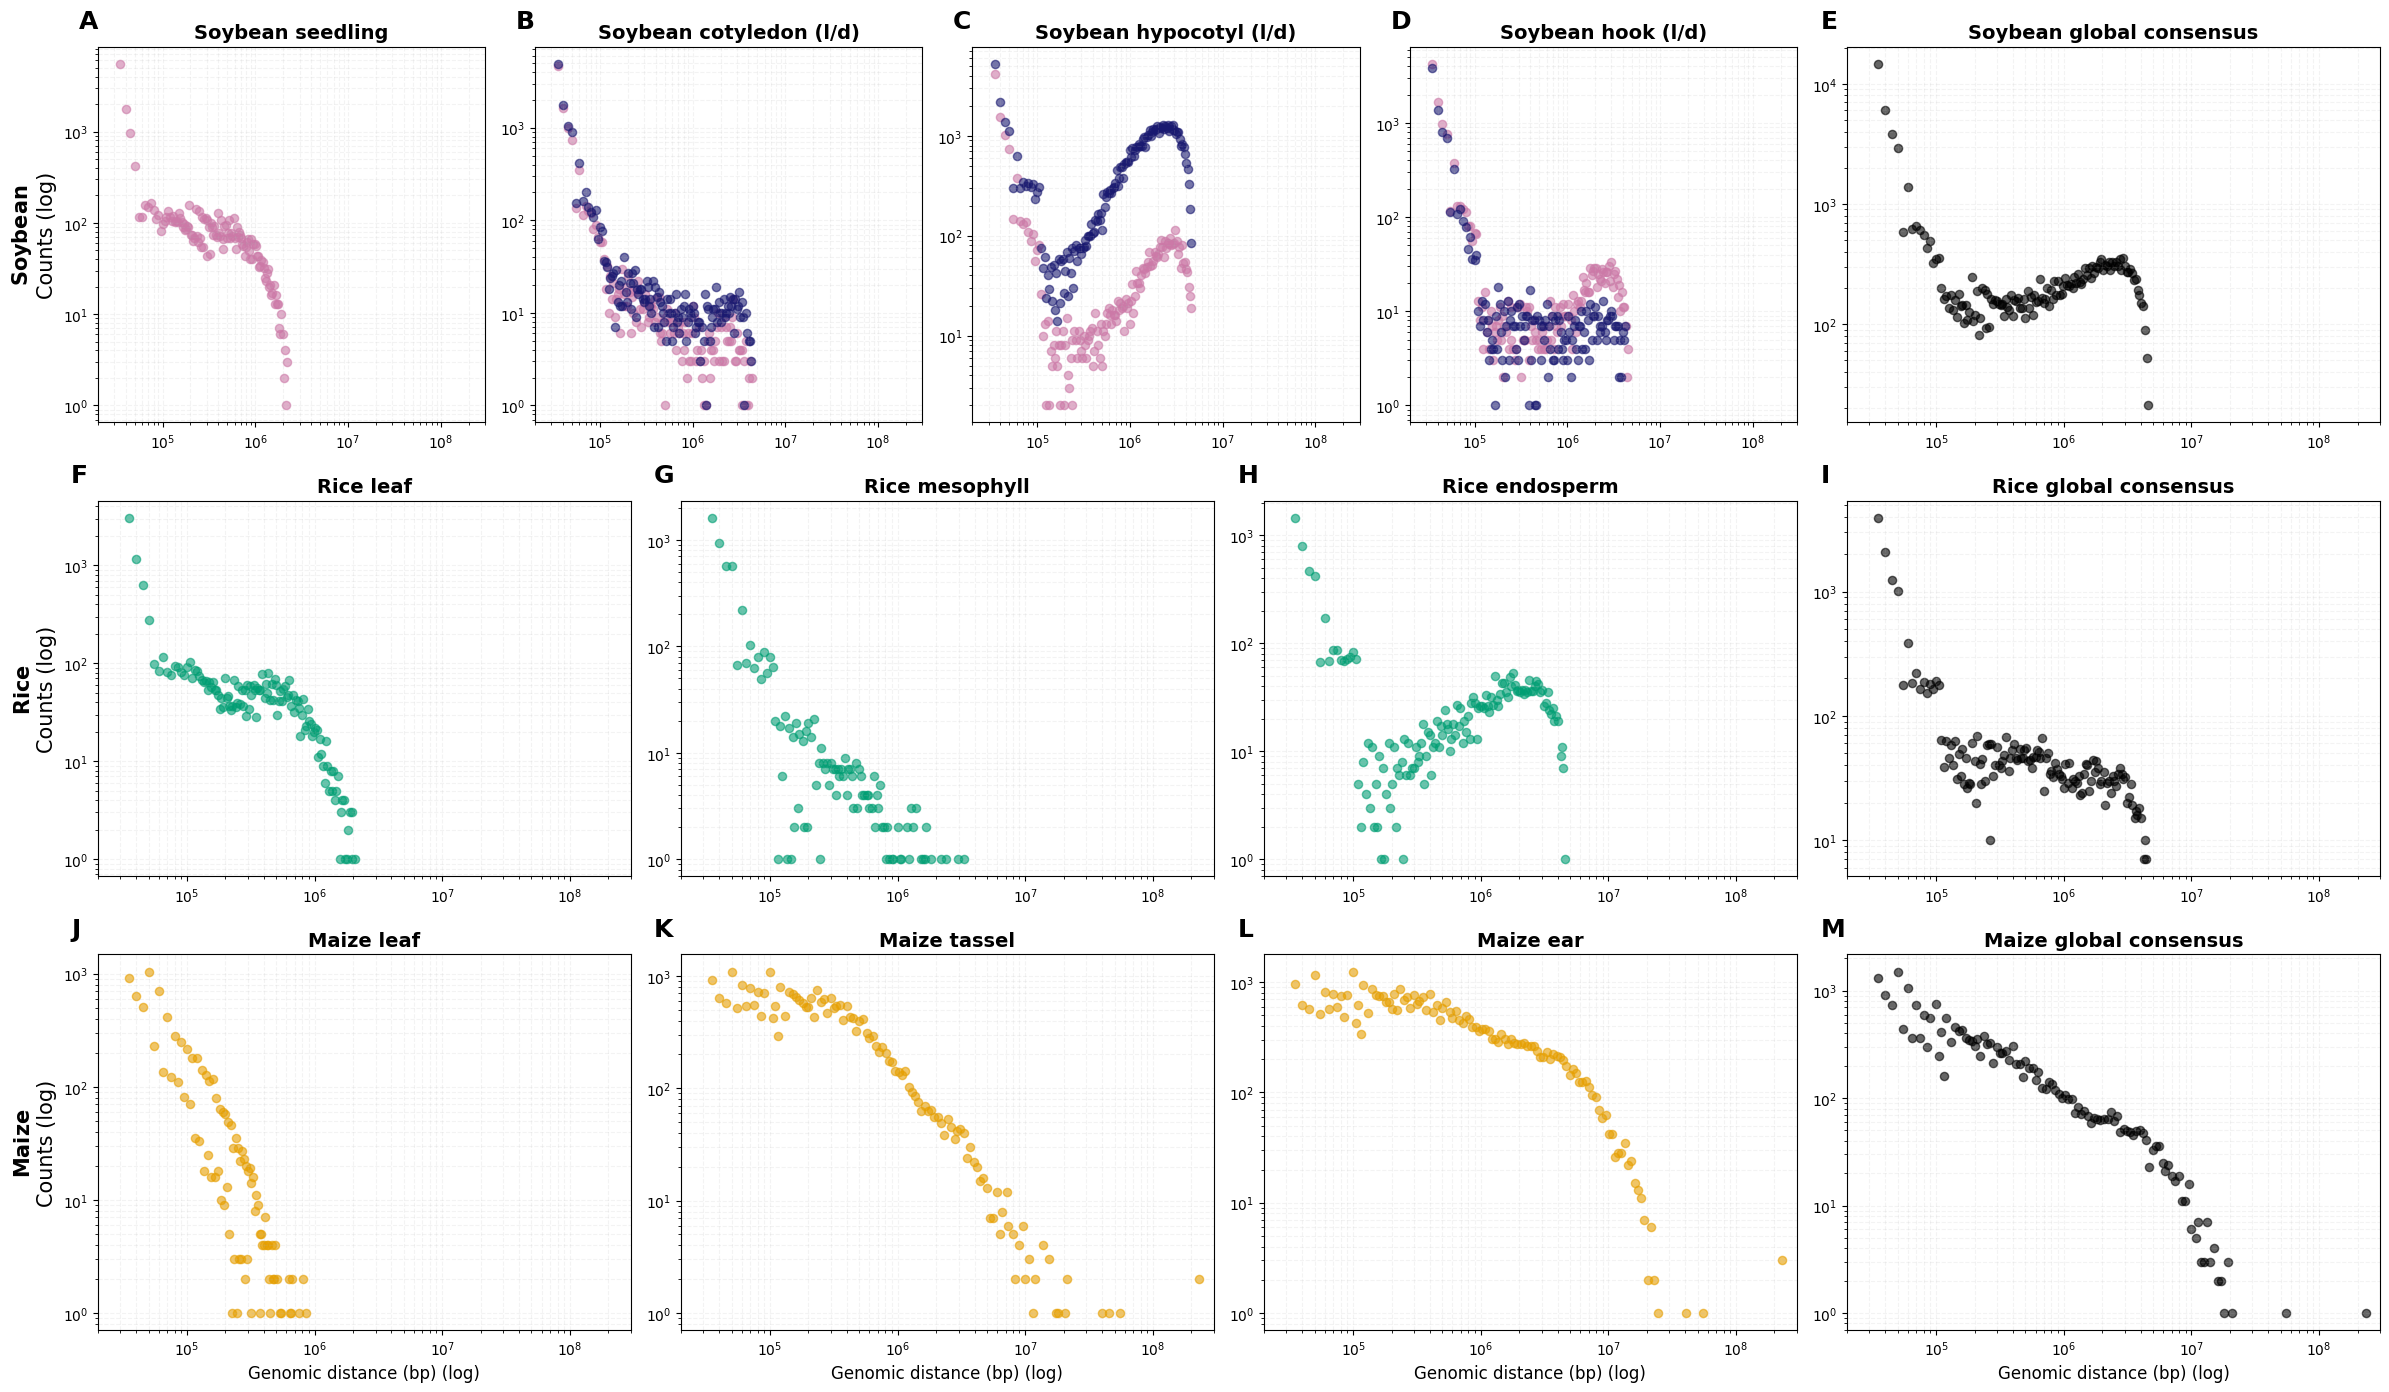

--- Generating Linear visualization ---


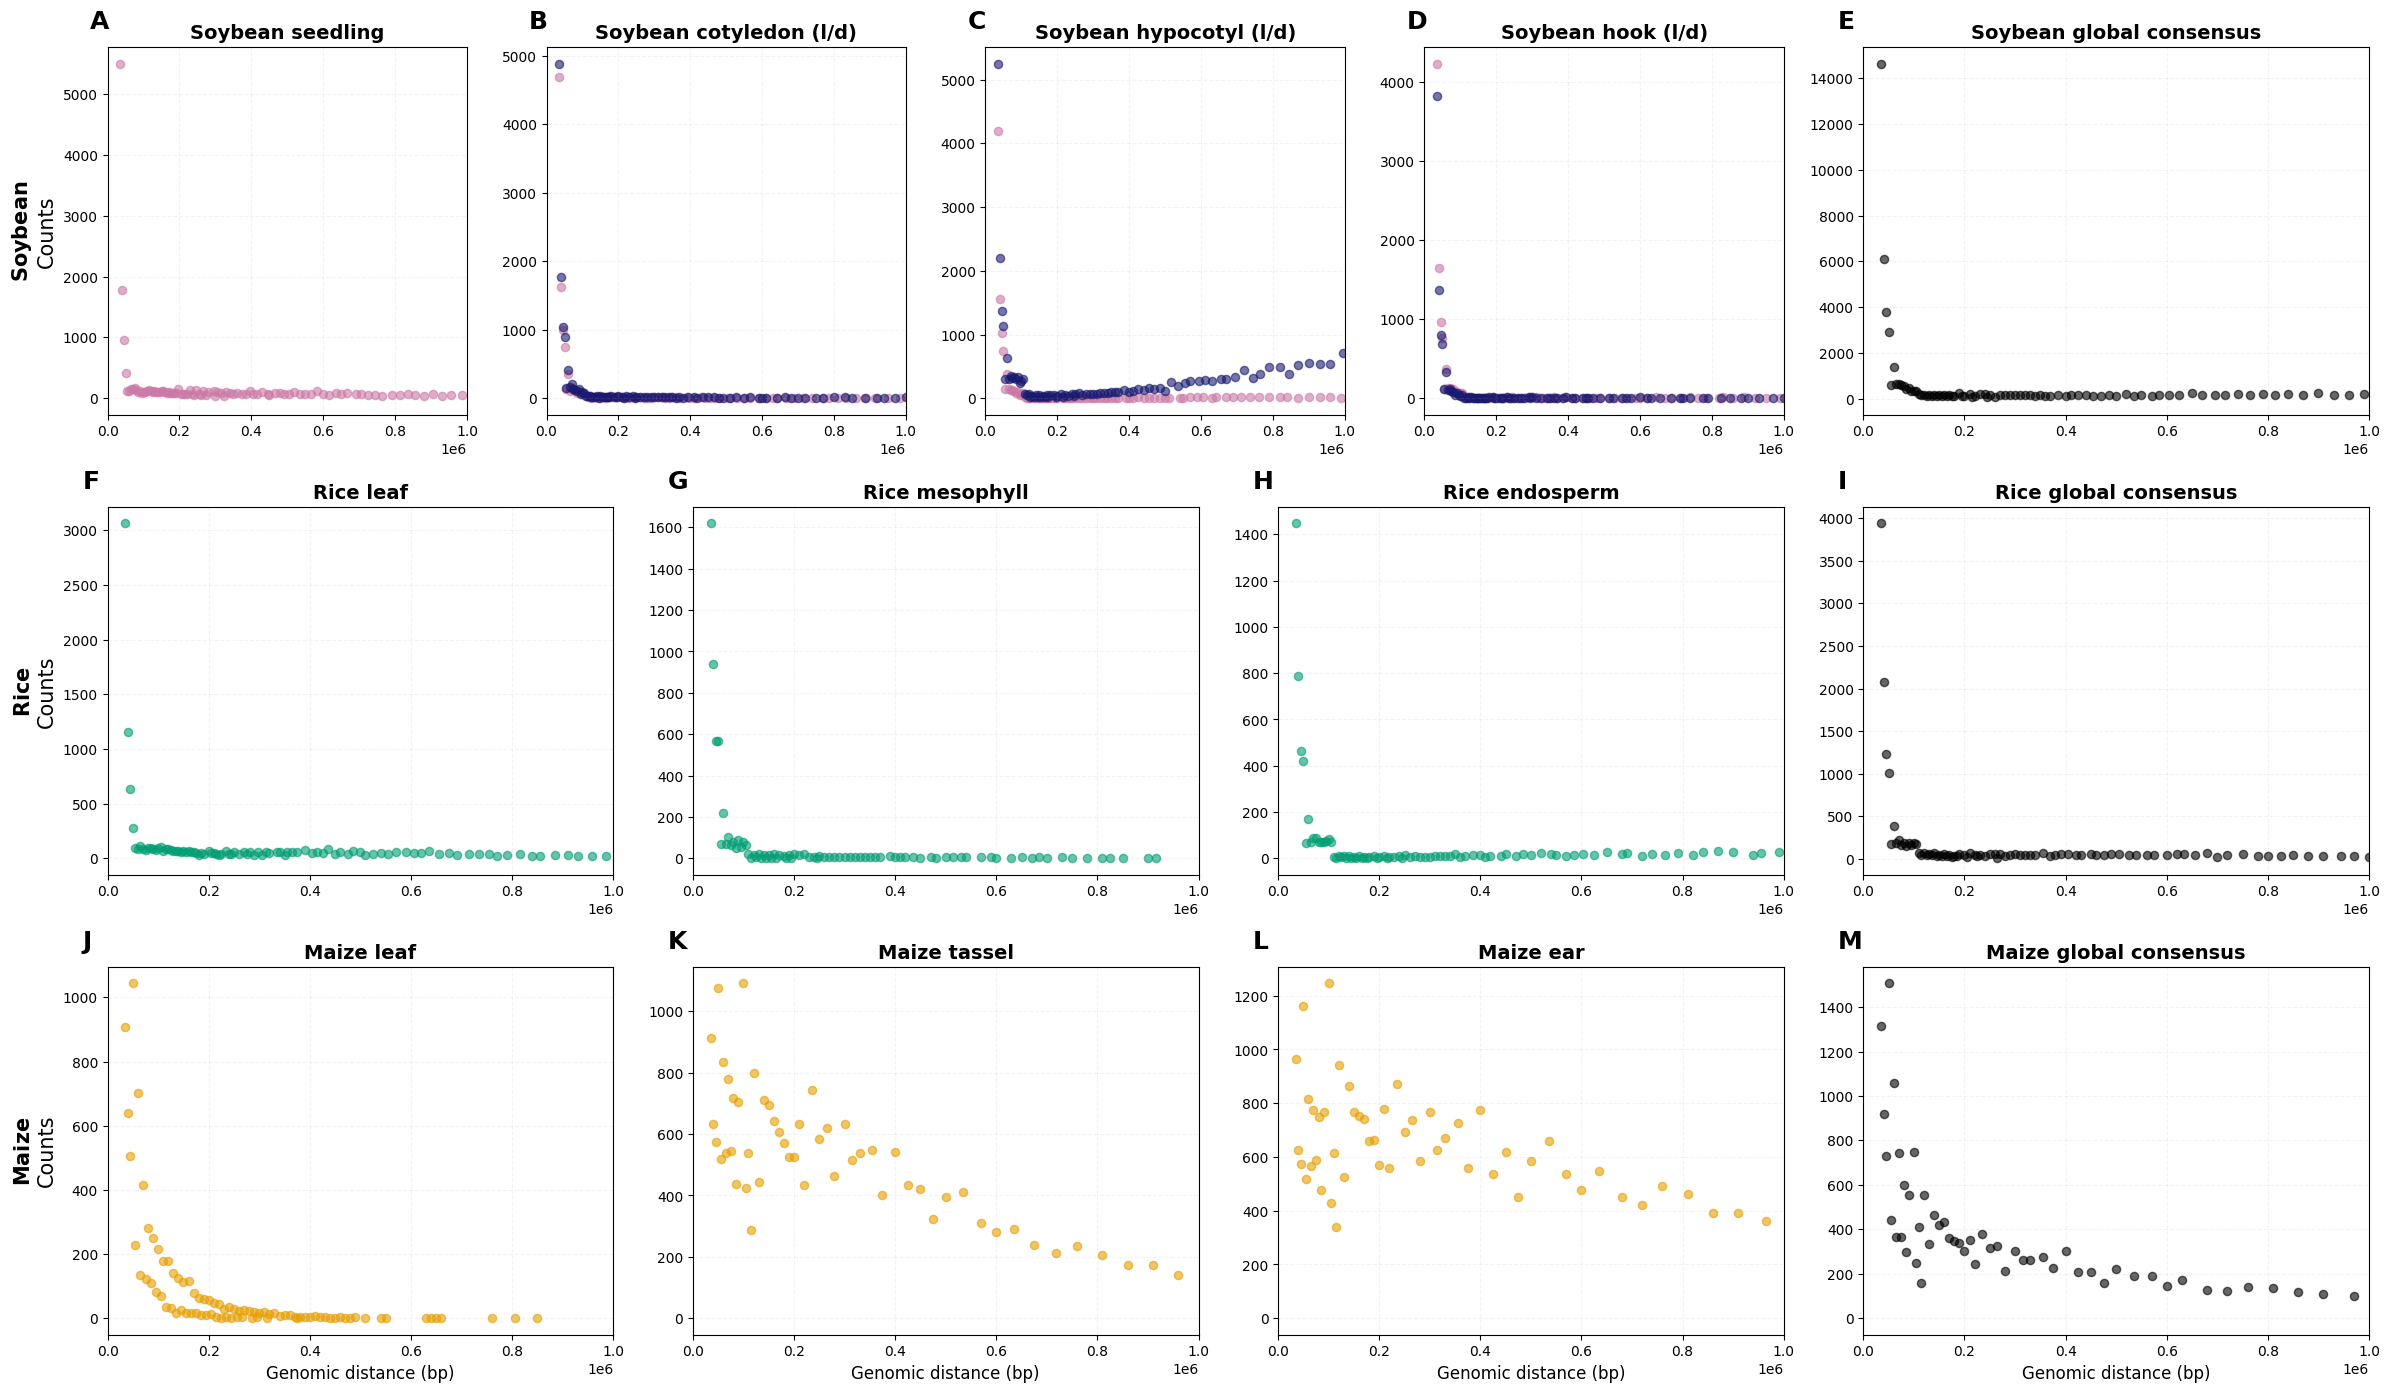

In [7]:
# ==============================================================================
# --- 5. Visual Validation: Hi-C Scaling Profiles (Linear & Log) ---
# ==============================================================================
import string
import matplotlib.gridspec as gridspec

# --- Configuration: Layout and Aesthetics ---
LAYOUT_MAP = {
    'SOYBEAN': [
        ('Soybean seedling', 0, 0, 3, ['soybean_leaf_hic']), 
        ('Soybean cotyledon (l/d)', 0, 3, 3, ['soybean_cotyledon_light_hic', 'soybean_cotyledon_dark_hic']), 
        ('Soybean hypocotyl (l/d)', 0, 6, 3, ['soybean_hypocotyl_light_hic', 'soybean_hypocotyl_dark_hic']), 
        ('Soybean hook (l/d)', 0, 9, 3, ['soybean_hook_light_hic', 'soybean_hook_dark_hic']),
        ('Soybean global consensus', 0, 12, 4, ['soybean_all_tissues'])
    ],
    'RICE': [
        ('Rice leaf', 1, 0, 4, ['rice_leaf_hic']), 
        ('Rice mesophyll', 1, 4, 4, ['rice_mesophyll_hic']), 
        ('Rice endosperm', 1, 8, 4, ['rice_endosperm_hic']), 
        ('Rice global consensus', 1, 12, 4, ['rice_all_tissues'])
    ],
    'MAIZE': [
        ('Maize leaf', 2, 0, 4, ['maize_leaf_hic']), 
        ('Maize tassel', 2, 4, 4, ['maize_tassel_hic']), 
        ('Maize ear', 2, 8, 4, ['maize_ear_hic']), 
        ('Maize global consensus', 2, 12, 4, ['maize_all_tissues'])
    ]
}

COLORS = {
    'Soybean': '#CC79A7', 'Rice': '#009E73', 'Maize': '#E69F00', 
    'Global': 'black', 'Dark': 'midnightblue'
}

def plot_all_species_hic(log_scale=True):
    """
    Plots loop-count vs distance for all tissues.
    Set log_scale=True for power-law view, False for linear view (first 1Mb).
    """
    def format_label(s):
        s = s.split('_hic')[0].replace('_', ' ')
        return s[0].upper() + s[1:]

    plt.rcParams['svg.fonttype'] = 'none' 
    fig = plt.figure(figsize=(24, 14))
    gs = gridspec.GridSpec(3, 16, figure=fig)
    all_axes = []
    
    mode = "Log-Log" if log_scale else "Linear"
    print(f"--- Generating {mode} visualization ---")

    for row_idx, species in enumerate(['SOYBEAN', 'RICE', 'MAIZE']):
        first_ax_in_row = True
        
        for title, row, col_start, width, keys in LAYOUT_MAP[species]:
            ax = fig.add_subplot(gs[row, col_start : col_start + width])
            all_axes.append(ax)
            
            for key in keys:
                df_raw = PROCESSED_HIC_DATA.get(key)
                if df_raw is None: continue
                _, df_plot = bin_and_count_distances(df_raw)
                
                # Color Selection
                if 'global' in title.lower(): c = COLORS['Global']
                elif 'dark' in key: c = COLORS['Dark']
                elif 'soybean' in key: c = COLORS['Soybean']
                elif 'rice' in key: c = COLORS['Rice']
                else: c = COLORS['Maize']

                ax.scatter(df_plot['bin_midpoint'], df_plot['count'], 
                           color=c, s=35, alpha=0.6, label=format_label(key))

            ax.set_title(title, fontsize=14, fontweight='bold')
            ax.grid(True, which="both", alpha=0.15, linestyle='--')
            
            if log_scale:
                ax.set_xscale('log'); ax.set_yscale('log')
                ax.set_xlim(2e4, 3e8)
            else:
                ax.set_xlim(0, 1e6) 

            if first_ax_in_row:
                unit = " (log)" if log_scale else ""
                ax.set_ylabel(r"$\bf{" + species.capitalize() + "}$" + f"\nCounts{unit}", fontsize=15)
                first_ax_in_row = False
            
            if row_idx == 2:
                unit = " (log)" if log_scale else ""
                ax.set_xlabel(f'Genomic distance (bp){unit}', fontsize=12)

    for ax, label in zip(all_axes, string.ascii_uppercase):
        ax.text(-0.05, 1.05, label, transform=ax.transAxes, fontsize=18, fontweight='bold')

    plt.tight_layout()
    plt.show()

# --- Execution ---
plot_all_species_hic(log_scale=True)
plot_all_species_hic(log_scale=False)

In [8]:
# ==============================================================================
# --- 6. GMM Selection: Parsimony-Driven Regime Detection ---
# ==============================================================================

# Global Constraints
GMM_MAX_DIST = 5_000_000             # Ignore noise/outliers beyond 5MB
ALPHA_SIGNIFICANCE_THRESHOLD = 0.25  # Minimum change in slope to justify a new regime
BIC_DROP_THRESHOLD = 20.0            # "Very Strong" statistical evidence barrier
MAX_K = 10 

def refined_model_selection(X_data, bic_thresh=BIC_DROP_THRESHOLD, alpha_thresh=ALPHA_SIGNIFICANCE_THRESHOLD):
    """
    Selects the optimal number of components (K) based on both BIC reduction 
    and significant changes in the scaling exponent (alpha).
    """
    bic_scores = []
    slope_history = {}
    
    # 1. Evaluate models from K=1 to MAX_K
    for n in range(1, MAX_K + 1):
        gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=0)
        gmm.fit(X_data)
        bic_scores.append(gmm.bic(X_data))
        
        # Extract slopes (alpha) and sort by distance (mean_x)
        props = []
        for k in range(n):
            # Slope in log-log space
            slope = gmm.covariances_[k][0, 1] / gmm.covariances_[k][0, 0]
            props.append({"mean_x": gmm.means_[k][0], "alpha": -slope})
        
        slope_history[n] = [p["alpha"] for p in sorted(props, key=lambda x: x["mean_x"])]

    # 2. Decision Logic: Step-wise increase K only if it adds significant value
    selected_n = 1
    for n in range(2, MAX_K + 1):
        prev_a = np.array(slope_history[n-1])
        curr_a = np.array(slope_history[n])
        
        # Calculate the maximum change in scaling exponents between K and K-1
        max_diff = max([min([abs(c - p) for p in prev_a]) for c in curr_a])
        bic_improvement = bic_scores[selected_n-1] - bic_scores[n-1]
        
        if bic_improvement > bic_thresh and max_diff > alpha_thresh:
            selected_n = n
        else:
            # Stop if the next component is redundant or statistically weak
            break 
            
    return selected_n, bic_scores, slope_history

# --- Execution of GMM Fitting ---
FINAL_GMM_RESULTS = {}
print(f"🚀 Running Selection (Capped at {GMM_MAX_DIST/1e6}MB)...")

# Flatten the LAYOUT_MAP to get all unique tissue/consensus keys
for species, groups in LAYOUT_MAP.items():
    for display_name, _, _, _, keys in groups:
        
        # Combine data for the specific group
        dfs = [PROCESSED_HIC_DATA.get(k) for k in keys if PROCESSED_HIC_DATA.get(k) is not None]
        if not dfs: continue
        
        df_group = pd.concat(dfs).drop_duplicates()
        # Apply the 5MB Cap
        df_filtered = df_group[df_group['distance'] <= GMM_MAX_DIST].copy()
        
        X_data, _ = bin_and_count_distances(df_filtered, num_bins=150)
        
        if X_data is not None:
            opt_n, bics, history = refined_model_selection(X_data)
            
            # Use the display_name as the primary key for the results
            FINAL_GMM_RESULTS[display_name] = {
                "n": opt_n, 
                "X_data": X_data,
                "raw_bic_min_k": np.argmin(bics) + 1, 
                "slopes": history[opt_n]
            }
            print(f"📊 {display_name:30} | Selected K={opt_n} (Raw BIC suggested K={np.argmin(bics)+1})")

🚀 Running Selection (Capped at 5.0MB)...
📊 Soybean seedling               | Selected K=3 (Raw BIC suggested K=5)
📊 Soybean cotyledon (l/d)        | Selected K=3 (Raw BIC suggested K=3)
📊 Soybean hypocotyl (l/d)        | Selected K=4 (Raw BIC suggested K=8)
📊 Soybean hook (l/d)             | Selected K=2 (Raw BIC suggested K=3)
📊 Soybean global consensus       | Selected K=3 (Raw BIC suggested K=9)
📊 Rice leaf                      | Selected K=3 (Raw BIC suggested K=5)
📊 Rice mesophyll                 | Selected K=3 (Raw BIC suggested K=7)
📊 Rice endosperm                 | Selected K=4 (Raw BIC suggested K=6)
📊 Rice global consensus          | Selected K=2 (Raw BIC suggested K=5)
📊 Maize leaf                     | Selected K=1 (Raw BIC suggested K=10)
📊 Maize tassel                   | Selected K=2 (Raw BIC suggested K=2)
📊 Maize ear                      | Selected K=1 (Raw BIC suggested K=3)
📊 Maize global consensus         | Selected K=2 (Raw BIC suggested K=3)


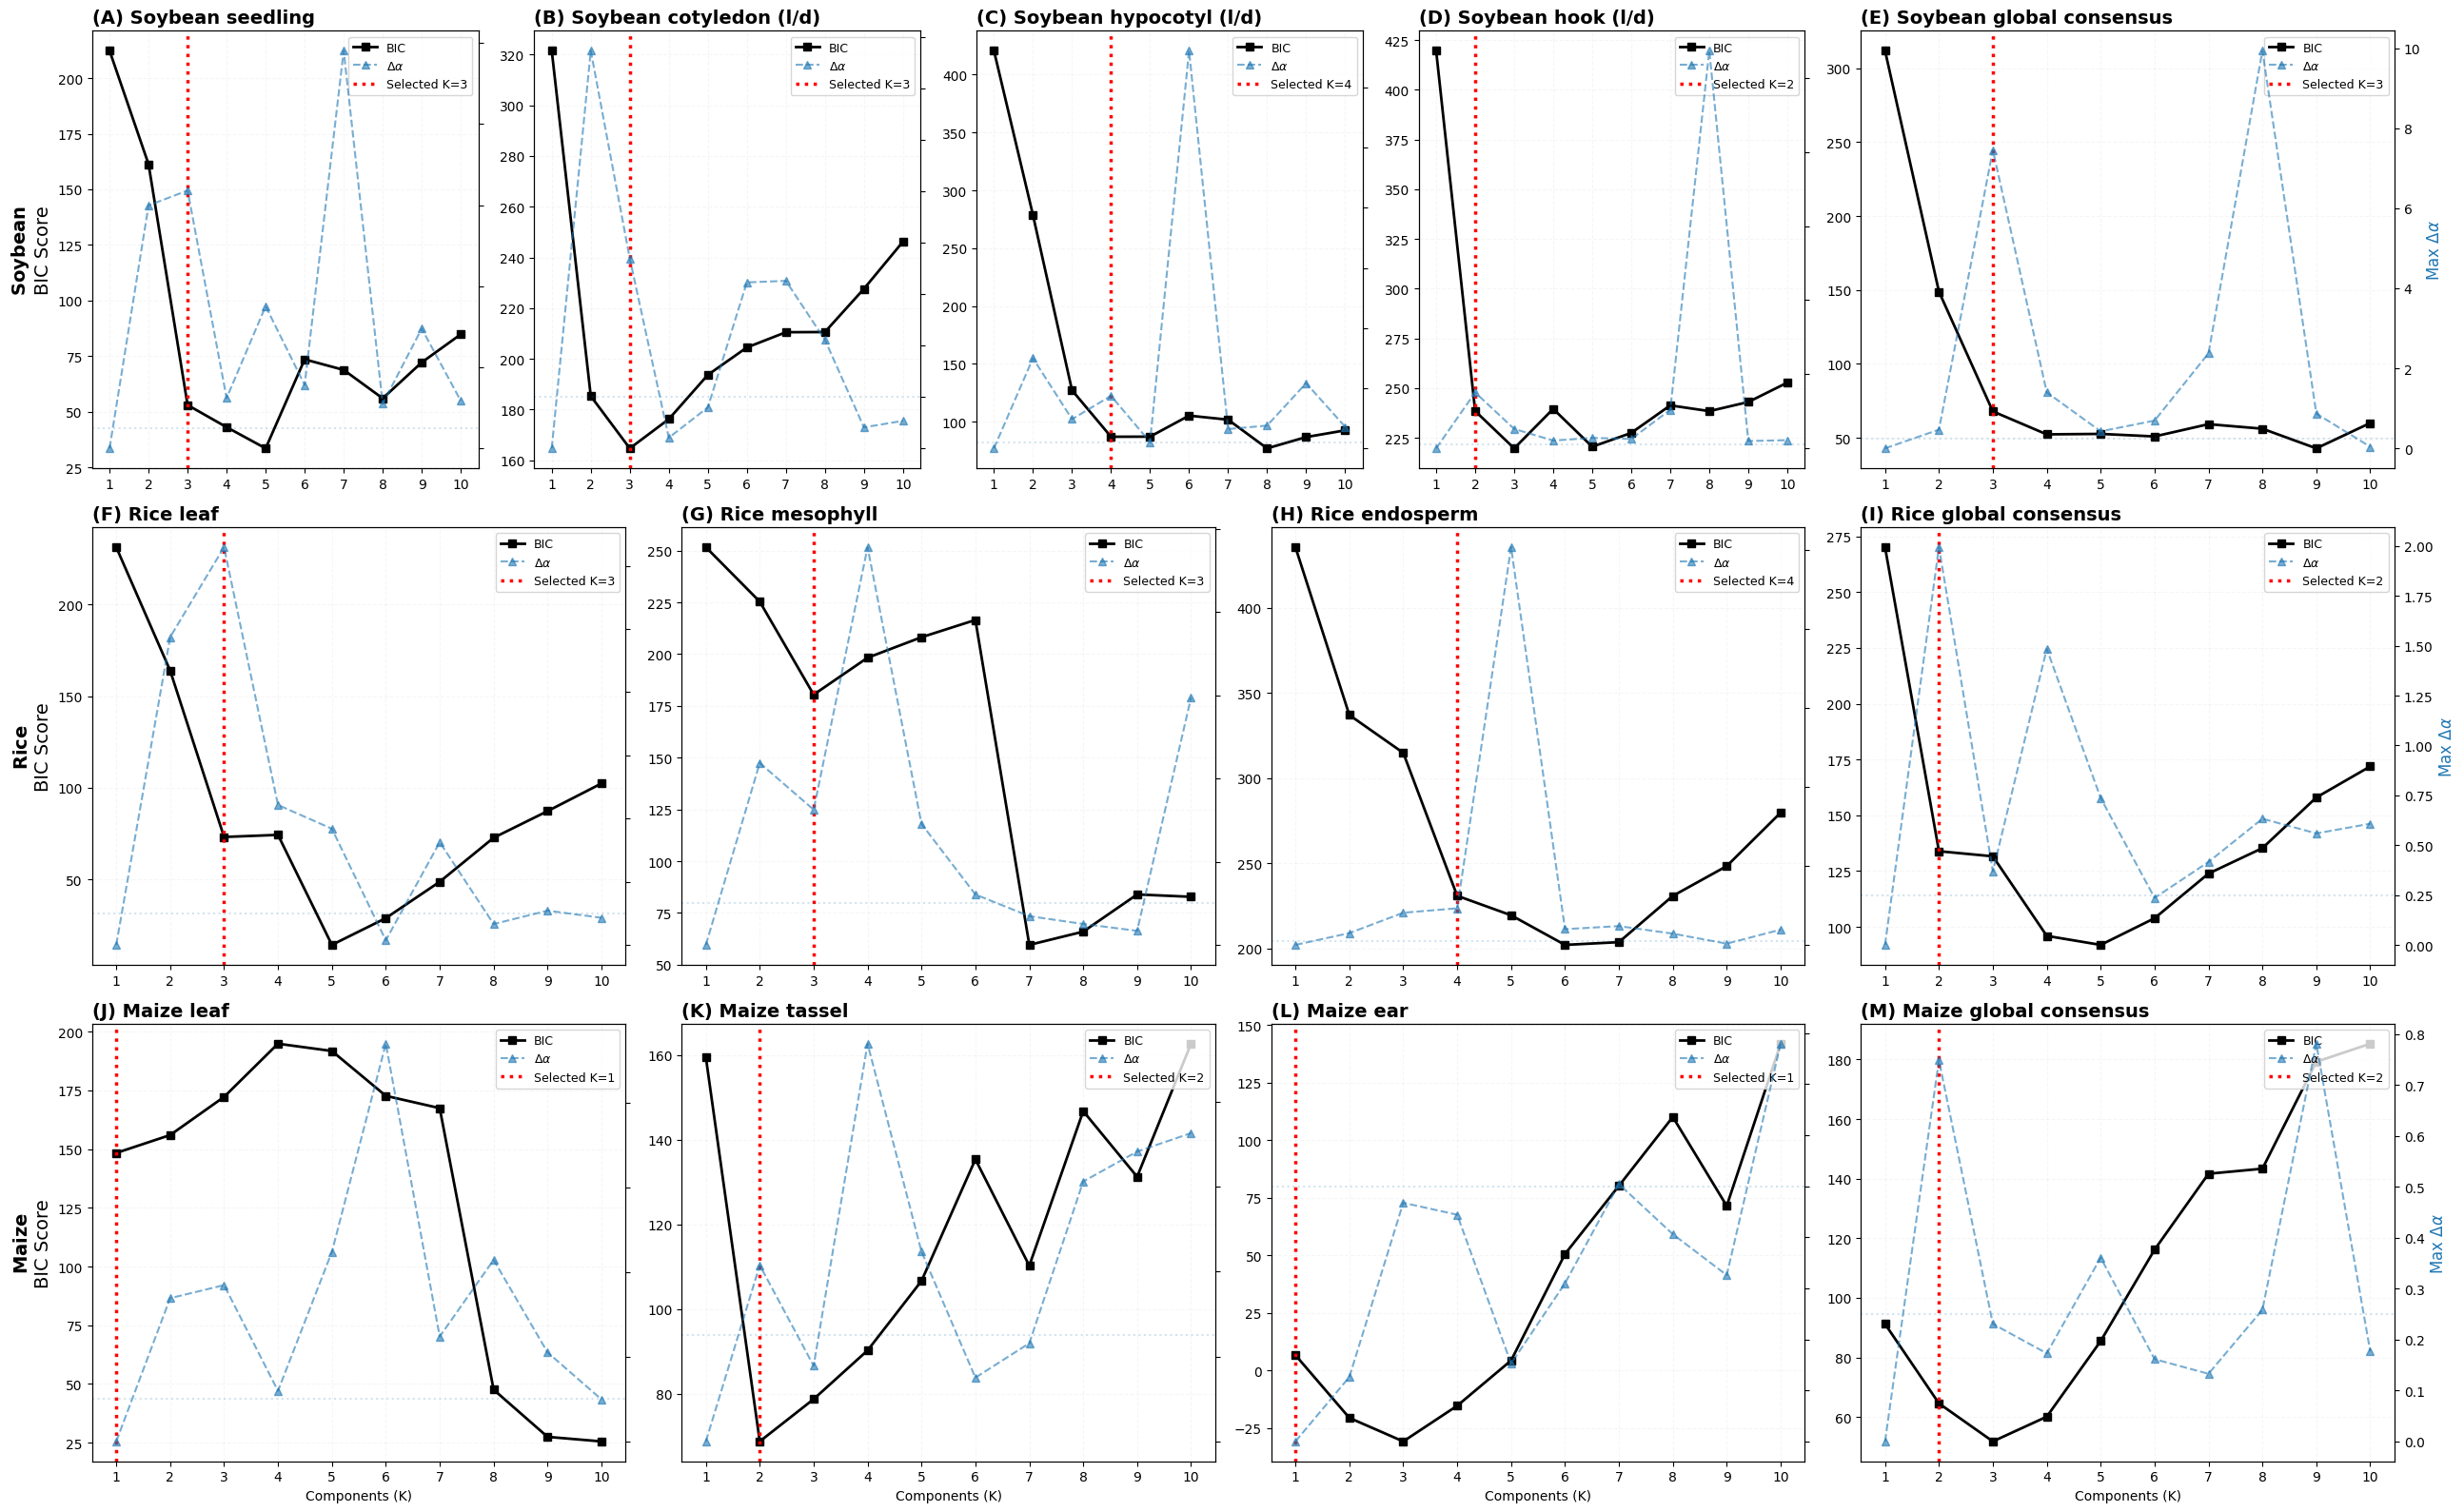

✅ Model selection visualization complete.


In [10]:
# ==============================================================================
# --- 7. Visualizing BIC and Slope Stability (Supplementary Figure S1) ---
# ==============================================================================
import warnings
import matplotlib.gridspec as gridspec
warnings.filterwarnings('ignore')

# --- Plotting Configuration ---
plt.rcParams['svg.fonttype'] = 'none'
panel_labels = [['A', 'B', 'C', 'D', 'E'], ['F', 'G', 'H', 'I'], ['J', 'K', 'L', 'M']]

fig = plt.figure(figsize=(26, 16))
gs = gridspec.GridSpec(3, 16, figure=fig)

# --- Main Plotting Loop ---
for row_idx, species in enumerate(['SOYBEAN', 'RICE', 'MAIZE']):
    datasets = LAYOUT_MAP[species]
    
    # We use *args to catch the 'keys' item that exists in some LAYOUT_MAP versions
    for d_idx, (display_name, row, col_start, col_span, *args) in enumerate(datasets):
        ax = fig.add_subplot(gs[row, col_start : col_start + col_span])
        
        # Retrieve results from our fitting step
        results = FINAL_GMM_RESULTS.get(display_name)
        if results is None:
            ax.axis('off')
            continue

        X_data = results['X_data']
        selected_k = results['n']

        # Re-calculate metrics for K=1-10 to generate curves
        bics, d_alphas = [], [0]
        slopes_by_k = {}
        
        for n in range(1, 11):
            gmm = GaussianMixture(n_components=n, covariance_type='full', random_state=0).fit(X_data)
            bics.append(gmm.bic(X_data))
            
            # Extract slopes for delta-alpha calculation
            props = [{"m": gmm.means_[k][0], "a": -(gmm.covariances_[k][0,1]/gmm.covariances_[k][0,0])} for k in range(n)]
            slopes_by_k[n] = [p["a"] for p in sorted(props, key=lambda x: x["m"])]
            
            if n > 1:
                prev_a, curr_a = np.array(slopes_by_k[n-1]), np.array(slopes_by_k[n])
                # Stability metric: how much does the 'new' slope differ from the closest 'old' slope?
                d_alphas.append(max([min([abs(c - p) for p in prev_a]) for c in curr_a]))

        # --- Layers ---
        # 1. BIC Score (Primary Y-axis)
        lns1 = ax.plot(range(1, 11), bics, marker='s', ls='-', label='BIC', color='black', lw=2)
        
        # 2. Delta Alpha (Secondary Y-axis)
        ax_alpha = ax.twinx()
        lns2 = ax_alpha.plot(range(1, 11), d_alphas, marker='^', color='tab:blue', ls='--', alpha=0.6, label=r'$\Delta \alpha$')
        ax_alpha.axhline(ALPHA_SIGNIFICANCE_THRESHOLD, color='tab:blue', alpha=0.2, ls=':')
        
        # 3. Parsimony Selection (Vertical Marker)
        lns3 = ax.axvline(selected_k, color='red', ls=':', lw=2.5, label=f'Selected K={selected_k}')
        
        # --- Aesthetics ---
        ax.set_title(f"({panel_labels[row_idx][d_idx]}) {display_name}", fontsize=14, fontweight='bold', loc='left')
        ax.set_xticks(range(1, 11))
        ax.grid(True, which="both", ls="--", alpha=0.1)
        
        # Legend construction
        lns = lns1 + lns2 + [lns3]
        labs = [l.get_label() for l in lns]
        ax.legend(lns, labs, loc='upper right', fontsize=9, frameon=True)

        if row == 2: ax.set_xlabel("Components (K)")
        if col_start == 0:
            ax.set_ylabel(r"$\bf{" + species.capitalize() + "}$" + "\nBIC Score", fontsize=14)
        
        if d_idx == len(datasets) - 1:
            ax_alpha.set_ylabel(r"Max $\Delta \alpha$", color='tab:blue', fontsize=12)
        else:
            ax_alpha.set_yticklabels([])

plt.tight_layout()
plt.show()

print("✅ Model selection visualization complete.")

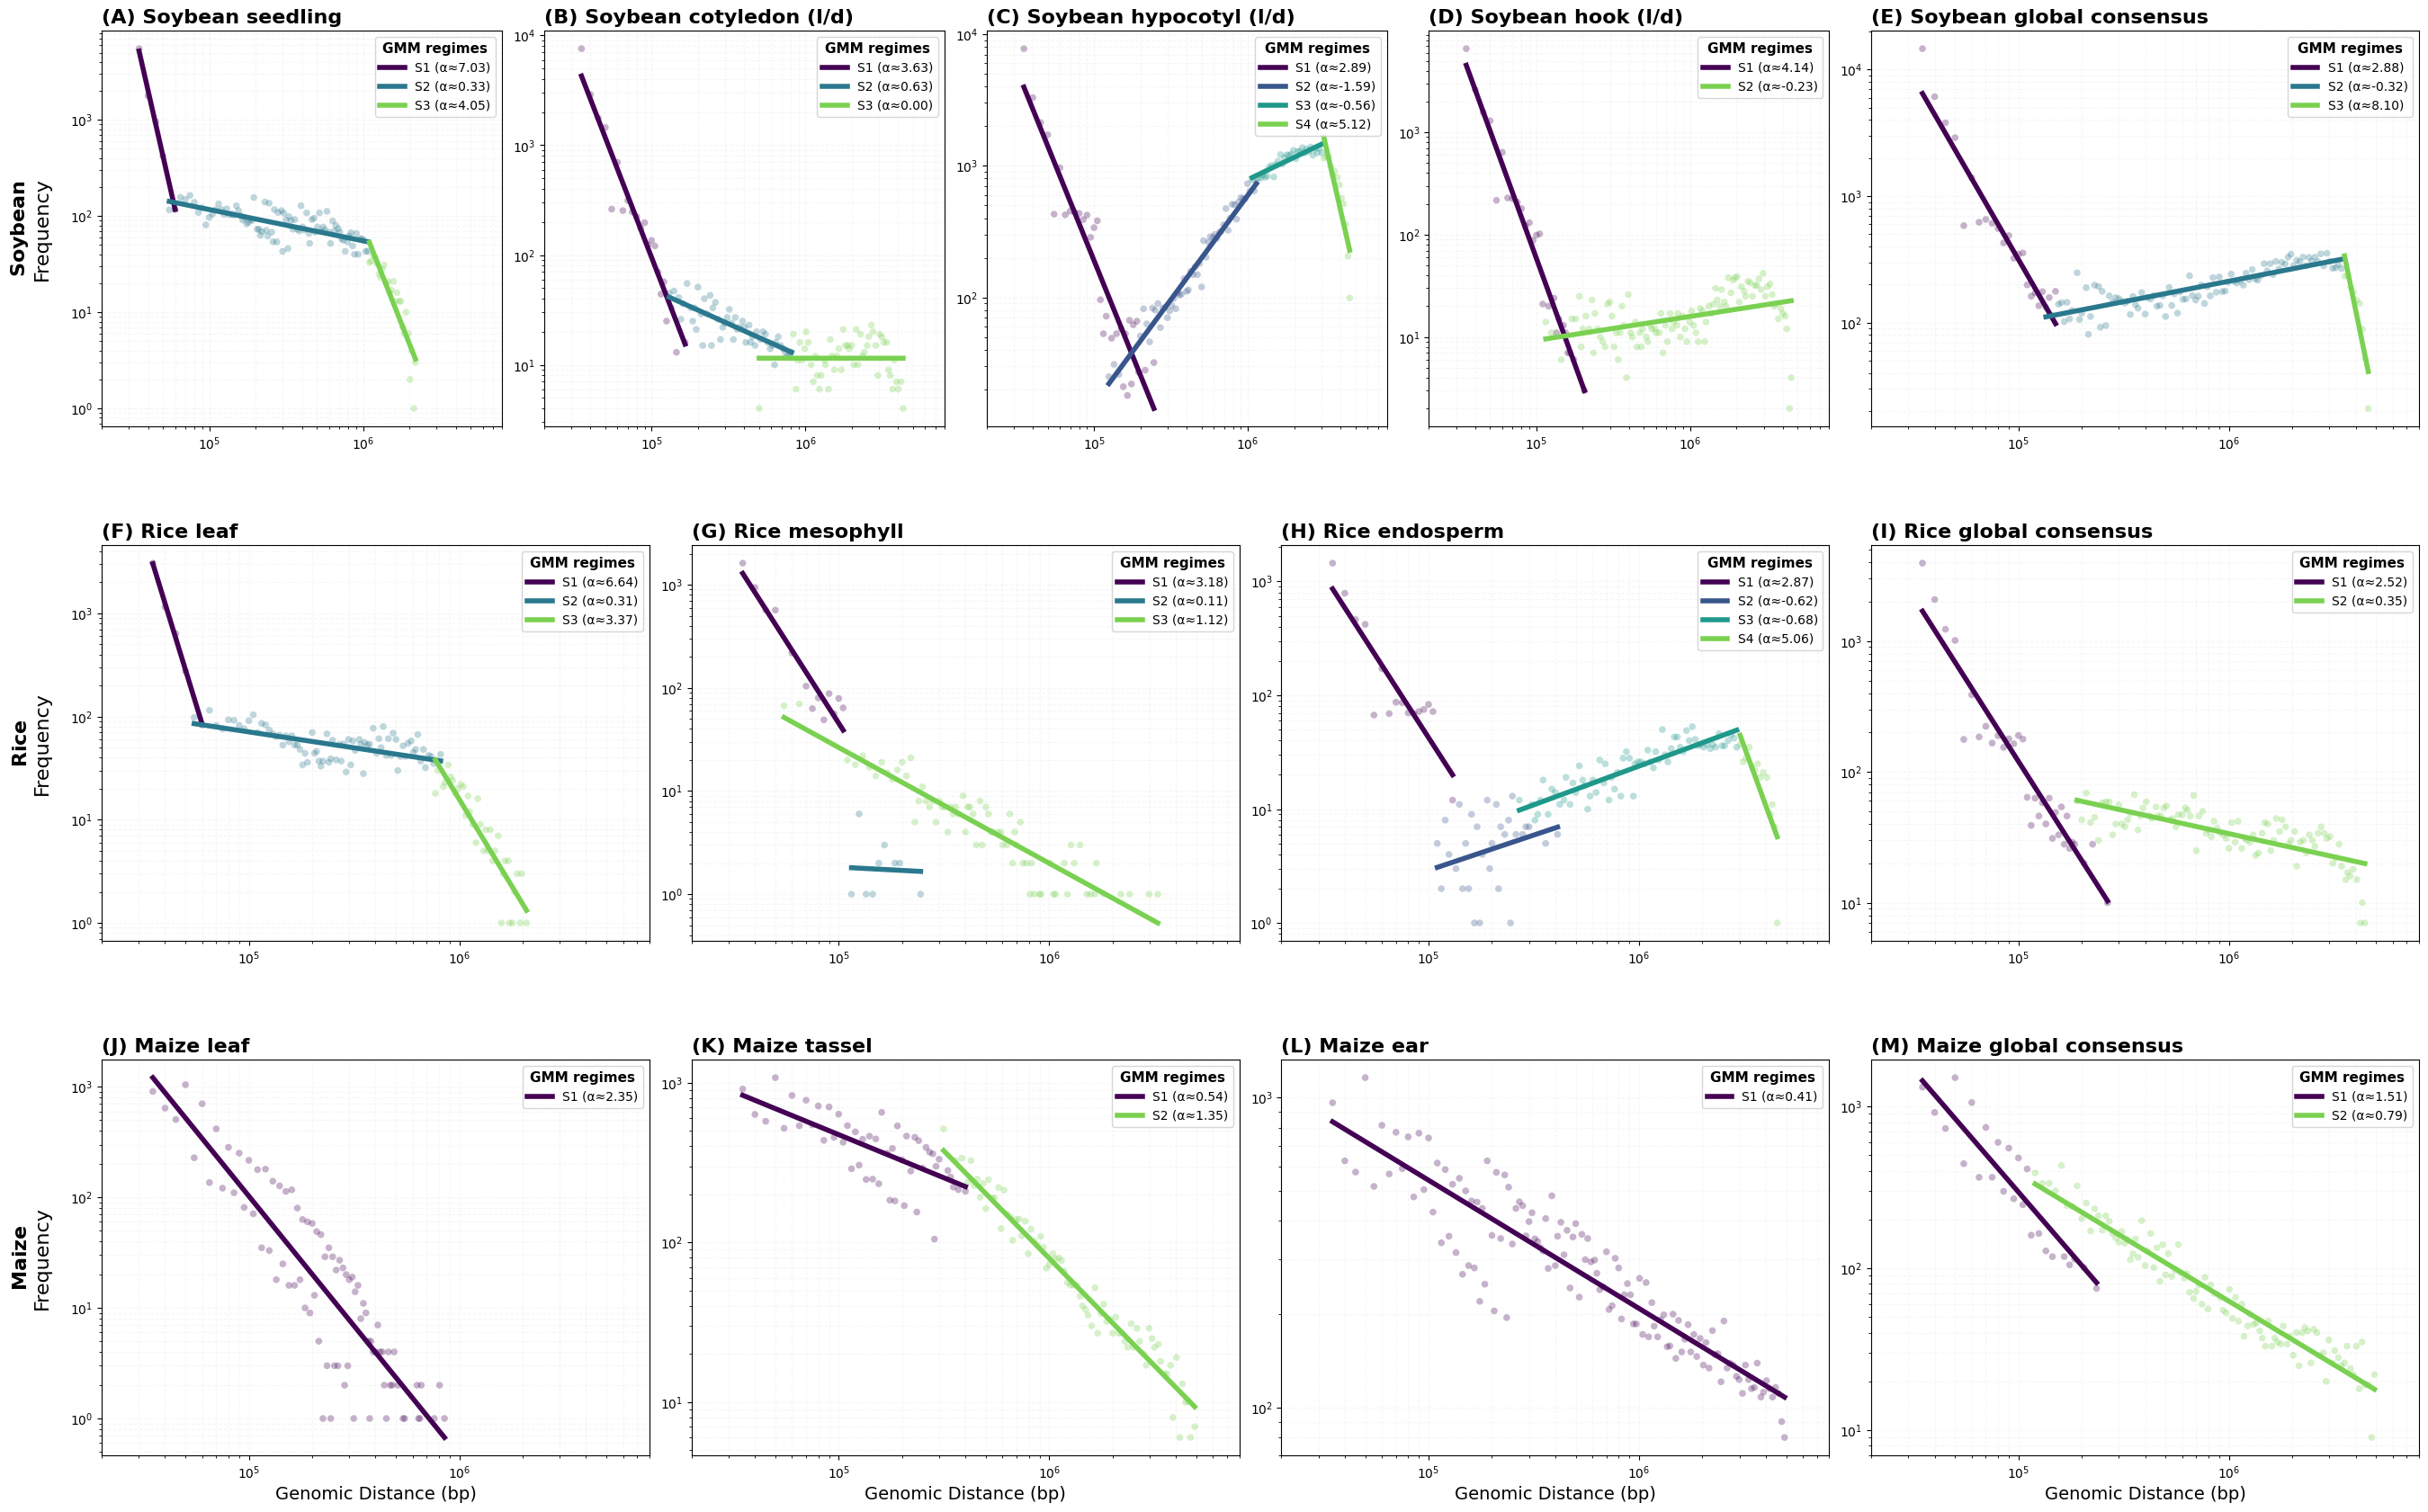


Dataset                        | K  | Alphas (slopes)           | Transitions (kb)    
--------------------------------------------------------------------------------
Soybean seedling               | 3  | [7.03, 0.33, 4.05]        | [58.6, 1097.6]      
Soybean cotyledon (l/d)        | 3  | [3.63, 0.63, 0.0]         | [124.9, 992.4]      
Soybean hypocotyl (l/d)        | 4  | [2.89, -1.59, -0.56, 5.12] | [175.2, 1305.7, 3176.2]
Soybean hook (l/d)             | 2  | [4.14, -0.23]             | [152.4]             
Soybean global consensus       | 3  | [2.88, -0.32, 8.1]        | [142.8, 3561.8]     
Rice leaf                      | 3  | [6.64, 0.31, 3.37]        | [60.2, 770.7]       
Rice mesophyll                 | 3  | [3.18, 0.11, 1.12]        | [284.0, 1390.0]     
Rice endosperm                 | 4  | [2.87, -0.62, -0.68, 5.06] | [215.9, 0.0, 2951.7]
Rice global consensus          | 2  | [2.52, 0.35]              | [123.5]             
Maize leaf                     | 1  | [2.35

In [11]:
# ==============================================================================
# --- 8. Visualizing GMM Scaling Regimes and Intersection Points ---
# ==============================================================================
from matplotlib import cm

# Initialization
DATASET_LEVEL_SUMMARY = []
species_list = ['SOYBEAN', 'RICE', 'MAIZE']
panel_labels = [['A', 'B', 'C', 'D', 'E'], ['F', 'G', 'H', 'I'], ['J', 'K', 'L', 'M']]

fig = plt.figure(figsize=(28, 18))
gs = gridspec.GridSpec(3, 16, figure=fig)

# --- Main Plotting Loop ---
for row_idx, species in enumerate(species_list):
    datasets = LAYOUT_MAP[species]
    
    for d_idx, (display_name, row, col_start, col_span, *extra) in enumerate(datasets):
        ax = fig.add_subplot(gs[row, col_start : col_start + col_span])
        
        config = FINAL_GMM_RESULTS.get(display_name)
        if config is None:
            ax.axis('off'); continue

        X_data = config["X_data"]
        optimal_k = int(config["n"])

        # 1. Final GMM Fit for this specific tissue
        gmm = GaussianMixture(n_components=optimal_k, covariance_type='full', random_state=0).fit(X_data)
        labels = gmm.predict(X_data)

        # 2. Parameter Extraction and Slope Sorting
        props = []
        for k in range(optimal_k):
            mean, cov = gmm.means_[k], gmm.covariances_[k]
            slope = cov[0, 1] / cov[0, 0]
            intercept = mean[1] - slope * mean[0]
            props.append({"mean_x": mean[0], "slope": slope, "intercept": intercept, "label": k})
        
        sorted_p = sorted(props, key=lambda p: p["mean_x"])
        colors = cm.viridis(np.linspace(0, 0.8, optimal_k))
        
        alphas, trans_kb = [], []
        
        # 3. Plotting Regimes and Lines
        for i, p in enumerate(sorted_p):
            mask = (labels == p["label"])
            # Scatter underlying binned data
            ax.scatter(10**X_data[mask, 0], 10**X_data[mask, 1], s=30, alpha=0.3, color=colors[i], edgecolors='none')
            
            # Draw the fitted power-law line
            lx = np.linspace(X_data[mask, 0].min(), X_data[mask, 0].max(), 100)
            ly = p["slope"] * lx + p["intercept"]
            ax.plot(10**lx, 10**ly, lw=4, color=colors[i], label=f'S{i+1} (α≈{-p["slope"]:.2f})')
            alphas.append(-p["slope"])

        # 4. Calculate Intersection-based Transitions (Ti)
        for i in range(len(sorted_p)-1):
            p1, p2 = sorted_p[i], sorted_p[i+1]
            # Solve for intersection: m1x + b1 = m2x + b2
            log_s = (p2["intercept"] - p1["intercept"]) / (p1["slope"] - p2["slope"])
            trans_kb.append((10**log_s)/1000)

        # Store results for the final summary table
        DATASET_LEVEL_SUMMARY.append({
            "Dataset": display_name, "K": optimal_k, 
            "alphas": [round(a, 2) for a in alphas],
            "trans_kb": [round(t, 1) for t in trans_kb]
        })

        # --- Formatting ---
        ax.set_xscale("log"); ax.set_yscale("log")
        ax.set_xlim(2e4, 8e6) 
        ax.set_title(f"({panel_labels[row][d_idx]}) {display_name}", fontsize=16, fontweight='bold', loc='left')
        ax.grid(True, which="both", ls="--", alpha=0.1)
        
        leg = ax.legend(title="GMM regimes", fontsize=10, title_fontsize=11, loc='upper right', frameon=True)
        leg.get_title().set_fontweight('bold')
        
        if row == 2: ax.set_xlabel("Genomic Distance (bp)", fontsize=14)
        if col_start == 0:
            species_label = species.capitalize()
            ax.set_ylabel(r"$\bf{" + species_label + "}$\nFrequency", fontsize=16, labelpad=15)

plt.subplots_adjust(left=0.06, right=0.98, top=0.96, bottom=0.08, wspace=0.4, hspace=0.3)
plt.show()

# --- Print the Almanac Summary ---
print("\n" + "="*80)
print(f"{'Dataset':<30} | {'K':<2} | {'Alphas (slopes)':<25} | {'Transitions (kb)':<20}")
print("-" * 80)
for row in DATASET_LEVEL_SUMMARY:
    print(f"{row['Dataset']:<30} | {row['K']:<2} | {str(row['alphas']):<25} | {str(row['trans_kb']):<20}")
print("="*80)

In [19]:
# ==============================================================================
# --- 9. Statistical Robustness: Bootstrapping (n=10,000) and Visualization ---
# ==============================================================================
from sklearn.linear_model import LinearRegression

def bootstrap_full_architecture(raw_df, n_components, n_boot=10000, random_state=42):
    rng = np.random.default_rng(random_state)
    results = []
    distances = raw_df['distance'].values
    N = len(distances)

    # Define genomic domain
    LOWER_BOUND_KB = 35.0   
    UPPER_BOUND_KB = 5000.0 
    
    for b in range(n_boot):
        resampled_dist = rng.choice(distances, size=N, replace=True)
        temp_df = pd.DataFrame({'distance': resampled_dist})
        X_boot, _ = bin_and_count_distances(temp_df, num_bins=150)
        
        if X_boot is None or len(X_boot) < n_components * 2:
            continue

        try:
            gmm = GaussianMixture(n_components=n_components, covariance_type='full', 
                                  random_state=int(rng.integers(0, 1e6)))
            labels = gmm.fit_predict(X_boot)
            
            props = []
            for k in range(n_components):
                mask = (labels == k)
                pts = X_boot[mask]
                if len(pts) < 2: continue
                reg = LinearRegression().fit(pts[:, 0].reshape(-1, 1), pts[:, 1])
                props.append({"mean_x": pts[:, 0].mean(), "slope": reg.coef_[0], "intercept": reg.intercept_})
            
            sorted_p = sorted(props, key=lambda x: x["mean_x"])
            if len(sorted_p) < n_components: continue

            # --- Extraction with Clipping ---
            a1 = -sorted_p[0]["slope"]
            
            # Intersection calculation
            p1, p2 = sorted_p[0], sorted_p[1]
            # Handle potential division by zero if lines are parallel
            denom = (p1["slope"] - p2["slope"])
            if abs(denom) < 1e-10:
                t1_kb = UPPER_BOUND_KB
            else:
                log_s = (p2["intercept"] - p1["intercept"]) / denom
                t1_kb = (10**log_s) / 1000
            
            # --- APPLY CONSTRAINTS ---
            # This is the crucial part that removes the 1e14 values
            t1_kb = np.clip(t1_kb, LOWER_BOUND_KB, UPPER_BOUND_KB)
            
            # Handle terminal regime for K=3
            a_end = -sorted_p[-1]["slope"]
            p_penult, p_last = sorted_p[-2], sorted_p[-1]
            denom_last = (p_penult["slope"] - p_last["slope"])
            if abs(denom_last) < 1e-10:
                tl_kb = UPPER_BOUND_KB
            else:
                log_sl = (p_last["intercept"] - p_penult["intercept"]) / denom_last
                tl_kb = np.clip((10**log_sl) / 1000, LOWER_BOUND_KB, UPPER_BOUND_KB)

            results.append({
                "Alpha_1": a1, "T1_kb": t1_kb,
                "Alpha_End": a_end, "T_Last_kb": tl_kb
            })
            
        except Exception:
            continue 

    return pd.DataFrame(results)


# 1. Run the Bootstrap Analysis
full_boot_results = {}
targets = [
    ('Maize', PROCESSED_HIC_DATA['maize_all_tissues'], 2),
    ('Soybean', PROCESSED_HIC_DATA['soybean_all_tissues'], 3),
    ('Rice', PROCESSED_HIC_DATA['rice_all_tissues'], 2)
]

for species, df, k in targets:
    print(f"🚀 Bootstrapping {species} (K={k})... 10,000 iterations.")
    full_boot_results[species] = bootstrap_full_architecture(df, k, n_boot=10000)

# 2. Extract Medians and CI for Plotting
plot_rows = []
for spec in ['Maize', 'Soybean', 'Rice']:
    res = full_boot_results[spec]
    row = {'Species': spec}
    for m in ['Alpha_1', 'T1_kb', 'Alpha_End', 'T_Last_kb']:
        low, med, high = np.percentile(res[m], [2.5, 50, 97.5])
        row[f"{m}_m"], row[f"{m}_l"], row[f"{m}_h"] = med, low, high
    plot_rows.append(row)

df_dynamic = pd.DataFrame(plot_rows)


🚀 Bootstrapping Maize (K=2)... 10,000 iterations.
🚀 Bootstrapping Soybean (K=3)... 10,000 iterations.
🚀 Bootstrapping Rice (K=2)... 10,000 iterations.


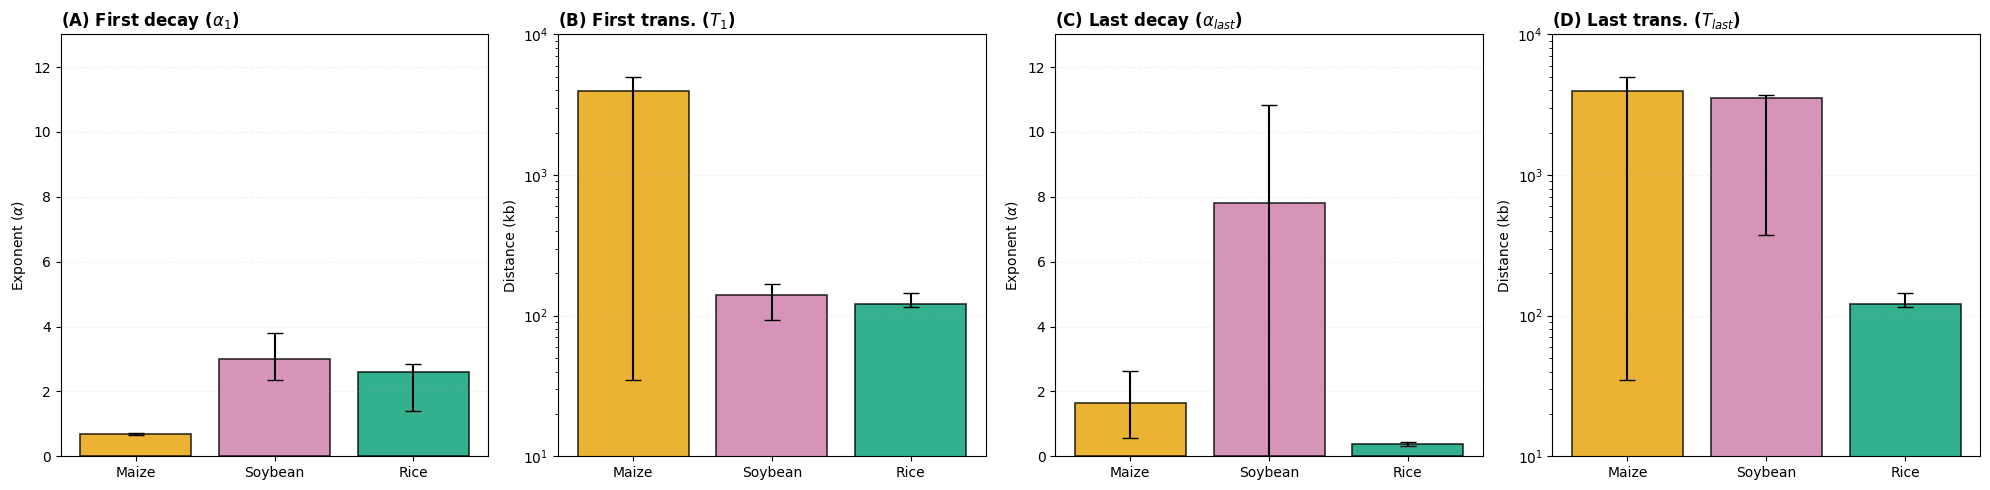

In [20]:
# ==============================================================================
# --- 10. Visualization: Horizontal 1x4 Stability Panel ---
# ==============================================================================

# 1. Processing results from full_boot_results
plot_rows = []
for spec in ['Maize', 'Soybean', 'Rice']:
    res = full_boot_results[spec]
    row = {'Species': spec}
    
    # Compute medians and 95% CI
    for m in ['Alpha_1', 'T1_kb', 'Alpha_End', 'T_Last_kb']:
        low, med, high = np.percentile(res[m], [2.5, 50, 97.5])
        row[f"{m}_m"], row[f"{m}_l"], row[f"{m}_h"] = med, low, high
    plot_rows.append(row)

df_plot = pd.DataFrame(plot_rows)

# 2. Plotting
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
colors_map = {'Maize': '#E69F00', 'Soybean': '#CC79A7', 'Rice': '#009E73'}

titles = [
    "(A) First decay ($\\alpha_1$)", "(B) First trans. ($T_1$)", 
    "(C) Last decay ($\\alpha_{last}$)", "(D) Last trans. ($T_{last}$)"
]

metrics = [
    ('Alpha_1_m', 'Alpha_1_l', 'Alpha_1_h'), ('T1_kb_m', 'T1_kb_l', 'T1_kb_h'),
    ('Alpha_End_m', 'Alpha_End_l', 'Alpha_End_h'), ('T_Last_kb_m', 'T_Last_kb_l', 'T_Last_kb_h')
]

for i, ax in enumerate(axes):
    m, l, h = metrics[i]
    yerr = [df_plot[m] - df_plot[l], df_plot[h] - df_plot[m]]
    
    ax.bar(df_plot['Species'], df_plot[m], yerr=yerr, 
           color=[colors_map[s] for s in df_plot['Species']], 
           capsize=6, alpha=0.8, edgecolor='black', linewidth=1.2)
    
    ax.set_title(titles[i], fontsize=12, fontweight='bold', loc='left')
    
    if "trans." in titles[i].lower():
        ax.set_yscale('log')
        ax.set_ylabel("Distance (kb)")
        ax.set_ylim(10, 10000) # Standard log range for genomic transitions
    else:
        ax.set_ylabel(r"Exponent ($\alpha$)")
        ax.set_ylim(0, max(df_plot['Alpha_End_h']) * 1.2) # Dynamic linear range
        
    ax.grid(True, axis='y', ls='--', alpha=0.15)

plt.tight_layout()
plt.show()



In [38]:
import pickle
import os

# The master dictionary to hold everything
FINAL_EXPORT_DATA = {
    'consensus': {},
    'tissue_specific': {}
}

print("📦 Exporting All Parameters (Consensus + Tissue-Specific)...")

# --- 1. Export Consensus (Species Level) ---
for spec in ['Maize', 'Soybean', 'Rice']:
    spec_key = spec.lower()
    if spec_key in FINAL_PENALTY_PARAMS:
        FINAL_EXPORT_DATA['consensus'][spec_key] = FINAL_PENALTY_PARAMS[spec_key]

# --- 2. Export Tissue-Specific (Detailed Level) ---
for species, datasets in LAYOUT_MAP.items():
    for d_info in datasets:
        # Handling the variable tuple length from earlier
        display_name = d_info[0] if isinstance(d_info[0], str) else d_info[4]
        
        # Get the GMM results we stored earlier
        res = FINAL_GMM_RESULTS.get(display_name)
        if res is None: continue
        
        # Calculate tissue-specific transitions (bp)
        # We use the GMM centers from the specific tissue fit
        gmm = GaussianMixture(n_components=res['n'], covariance_type='full', random_state=0).fit(res["X_data"])
        props = []
        for k in range(res['n']):
            m = gmm.covariances_[k][0,1] / gmm.covariances_[k][0,0]
            b = gmm.means_[k][1] - m * gmm.means_[k][0]
            props.append({"mean_x": gmm.means_[k][0], "alpha": -m, "intercept": b})
        
        sorted_p = sorted(props, key=lambda x: x["mean_x"])
        
        # Calculate intersections for this specific tissue
        t_bp = []
        for i in range(len(sorted_p)-1):
            p1, p2 = sorted_p[i], sorted_p[i+1]
            log_s = (p2["intercept"] - p1["intercept"]) / (p1["slope"] - p2["slope"]) if 'slope' in p1 else (p2["intercept"] - p1["intercept"]) / ((-p1["alpha"]) - (-p2["alpha"]))
            t_bp.append(round(10**log_s))

        # Store using the display_name as key (e.g., 'Rice endosperm')
        FINAL_EXPORT_DATA['tissue_specific'][display_name] = {
            'alphas': [round(p['alpha'], 4) for p in sorted_p],
            'transitions_bp': t_bp,
            'n_regimes': res['n']
        }

# --- Save to File ---
os.makedirs("penalty_functions", exist_ok=True)
output_path = "penalty_parameters.pkl"

with open(output_path, 'wb') as f:
    pickle.dump(FINAL_EXPORT_DATA, f)

print(f"\n🎉 DONE: {len(FINAL_EXPORT_DATA['tissue_specific'])} tissues saved to {output_path}")

📦 Exporting All Parameters (Consensus + Tissue-Specific)...

🎉 DONE: 13 tissues saved to penalty_parameters.pkl
